## 1. State Space for Each Altitude Layer

For each altitude layer $i \in \{1, 2, ..., L\}$, the state of the system at time $t$ is given by the set of aircraft present in that layer and their respective positions. Let $N_i(t)$ be the number of aircraft in layer $i$ at time $t$. Assuming a 2D horizontal plane for simplicity, the state $S_i(t)$ can be represented as:

$$S_i(t) = \{ (x_{i,1}(t), y_{i,1}(t)), (x_{i,2}(t), y_{i,2}(t)), ..., (x_{i,N_i(t)}(t), y_{i,N_i(t)}(t)) \}$$

where $(x_{i,j}(t), y_{i,j}(t))$ denotes the horizontal coordinates of the $j$-th aircraft in layer $i$ at time $t$. We can extend this to 3D by including the altitude $z_i$ (which is constant for a given layer) if needed for future considerations.

## 2. Independent Poisson Process for Each Layer

The arrival of aircraft into altitude layer $i$ is modeled as a homogeneous Poisson process with a rate $\lambda_i$. This rate represents the average number of aircraft entering layer $i$ per unit time. The probability of $k$ arrivals in layer $i$ during a time interval $\Delta t$ is given by:

$$P(N_i(\Delta t) = k) = \frac{(\lambda_i \Delta t)^k e^{-\lambda_i \Delta t}}{k!}, \quad k = 0, 1, 2, ...$$

In a more general case, the arrival rate can be spatially varying, denoted by $\lambda_i(x, y)$, to account for different traffic densities within the airspace. The expected number of arrivals in a region $A$ of layer $i$ during $\Delta t$ would then be $\int_A \lambda_i(x, y) dx dy \cdot \Delta t$. For our initial simulation, we will assume a constant $\lambda_i$ for each layer.


## 3. Compound Poisson Process for Vertical Transitions

Vertical transitions between altitude layers are modeled using a compound Poisson process.

* Let $\gamma_{i \to j}$ be the transition rate from layer $i$ to layer $j$ ($i \neq j$). We can organize these rates in a transition rate matrix $\Gamma$, where $\Gamma_{ij} = \gamma_{i \to j}$ for $i \neq j$, and $\Gamma_{ii} = - \sum_{j \neq i} \gamma_{i \to j}$ represents the total rate of an aircraft leaving layer $i$.

* The number of transitions from layer $i$ to layer $j$ in a small time interval $\Delta t$, given $N_i(t)$ aircraft in layer $i$, can be approximated by a Poisson process with rate $N_i(t) \gamma_{i \to j} \Delta t$ for small $\Delta t$.

* Alternatively, we can think of each aircraft in layer $i$ having a probability $\gamma_{i \to j} \Delta t$ of transitioning to layer $j$ during $\Delta t$.

* We can also define a probability distribution $p_{i \to j}$ for the destination layer $j$ given that a transition from layer $i$ occurs. Then, $\gamma_{i \to j} = \gamma_i \cdot p_{i \to j}$, where $\gamma_i = \sum_{j \neq i} \gamma_{i \to j}$ is the total departure rate from layer $i$.

## 4. Probability of Collision

A collision is defined as two aircraft being within a minimum safe separation distance $d_{safe}$ at the same time.

* **Collision within the same layer $i$:** A collision between aircraft $j$ and $k$ in layer $i$ at time $t$ occurs if:
    $$\sqrt{(x_{i,j}(t) - x_{i,k}(t))^2 + (y_{i,j}(t) - y_{i,k}(t))^2} \le d_{safe}$$
    Deriving an analytical probability of this event directly from the Poisson process is complex due to the dynamic nature of aircraft positions. Simulation will be used to estimate the frequency of such events.

* **Collision between different layers $i$ and $j$:** This occurs when an aircraft transitioning vertically is within $d_{safe}$ of an aircraft in the other layer at the time of, or during, the transition. The probability depends on the transition rates, the time taken for transition (which we are currently assuming to be instantaneous at the time step), and the densities in both layers. Again, simulation will be key to understanding this risk.

For our initial simulation, we will primarily focus on detecting collision events during each time step based on the proximity of aircraft.

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Number of layers
num_layers = 3
# Horizontal airspace dimensions (for simplicity, a square)
airspace_size = 100  # Units: arbitrary
# Simulation duration
simulation_time = 200  # Let's run for a bit longer
# Time step for simulation
dt = 1

# Arrival rates for each layer (average per time step)
arrival_rates = [0.3, 0.5, 0.2]

# Vertical transition rates (probability per time step for one aircraft)
transition_rates = np.array([
    [0, 0.02, 0.01],  # From layer 1 to 2, 3
    [0.015, 0, 0.025], # From layer 2 to 1, 3
    [0.01, 0.015, 0]   # From layer 3 to 1, 2
])

# Minimum safe separation distance
safe_distance = 5

# Aircraft speed (constant)
aircraft_speed = 2

# Lists to store aircraft in each layer and collision events
aircraft = [[] for _ in range(num_layers)]
collisions = []

In [3]:
for t in range(simulation_time):
    # 1. Aircraft Arrivals
    for i in range(num_layers):
        num_arrivals = np.random.poisson(arrival_rates[i] * dt)
        for _ in range(num_arrivals):
            x = random.uniform(0, airspace_size)
            y = random.uniform(0, airspace_size)
            angle = random.uniform(0, 2 * np.pi)
            vx = aircraft_speed * np.cos(angle)
            vy = aircraft_speed * np.sin(angle)
            aircraft[i].append({'x': x, 'y': y, 'vx': vx, 'vy': vy, 'layer': i, 'id': f'A{i}_{len(aircraft[i])}_{t}'})

    # 2. Aircraft Movement
    for i in range(num_layers):
        for craft in aircraft[i]:
            craft['x'] += craft['vx'] * dt
            craft['y'] += craft['vy'] * dt
            # Simple periodic boundary conditions
            if craft['x'] > airspace_size: craft['x'] -= airspace_size
            elif craft['x'] < 0: craft['x'] += airspace_size
            if craft['y'] > airspace_size: craft['y'] -= airspace_size
            elif craft['y'] < 0: craft['y'] += airspace_size

    # 3. Vertical Transitions
    for i in range(num_layers):
        aircraft_to_remove = []
        aircraft_to_add = []
        for idx, craft in enumerate(aircraft[i]):
            for j in range(num_layers):
                if i != j:
                    prob_transition = transition_rates[i, j] * dt
                    if random.random() < prob_transition:
                        aircraft_to_remove.append(craft['id'])
                        aircraft_to_add.append({'x': craft['x'], 'y': craft['y'], 'vx': craft['vx'], 'vy': craft['vy'], 'layer': j, 'id': craft['id']})
                        break

        aircraft[i] = [craft for craft in aircraft[i] if craft['id'] not in aircraft_to_remove]
        for craft in aircraft_to_add:
            aircraft[craft['layer']].append(craft)

    # 4. Collision Detection
    for i in range(num_layers):
        for j1 in range(len(aircraft[i])):
            for j2 in range(j1 + 1, len(aircraft[i])):
                craft1 = aircraft[i][j1]
                craft2 = aircraft[i][j2]
                distance = np.sqrt((craft1['x'] - craft2['x'])**2 + (craft1['y'] - craft2['y'])**2)
                if distance <= safe_distance:
                    collisions.append({'time': t, 'aircraft_ids': (craft1['id'], craft2['id']), 'layer': i})

    for i in range(num_layers):
        for j in range(i + 1, num_layers):
            for craft1 in aircraft[i]:
                for craft2 in aircraft[j]:
                    distance = np.sqrt((craft1['x'] - craft2['x'])**2 + (craft1['y'] - craft2['y'])**2)
                    if distance <= safe_distance:
                        collisions.append({'time': t, 'aircraft_ids': (craft1['id'], craft2['id']), 'layers': (i, j)})

Total collisions: 10851


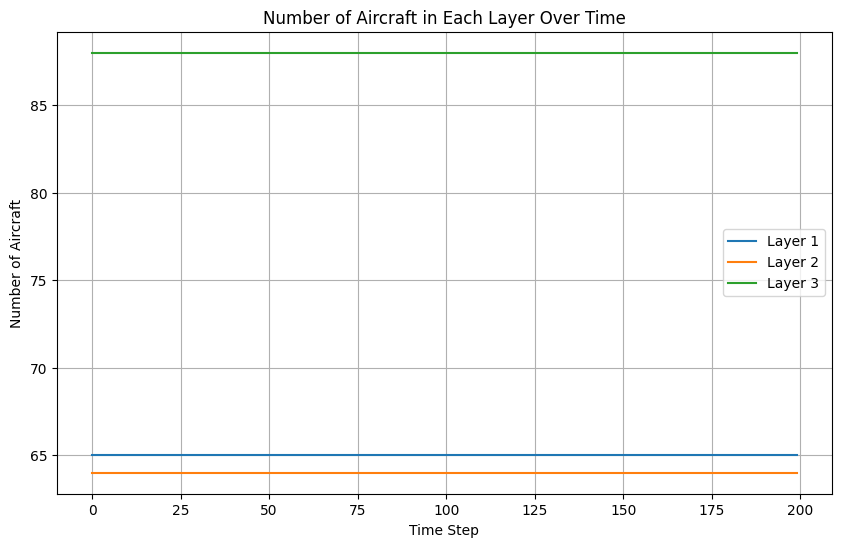

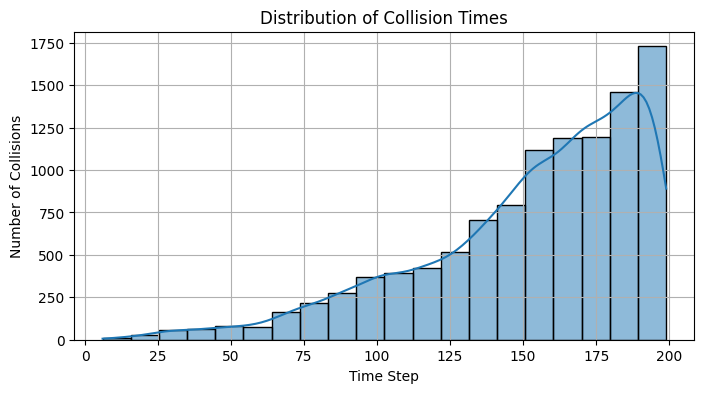

In [4]:
print(f"Total collisions: {len(collisions)}")

# Visualize the number of aircraft in each layer over time
aircraft_counts = [[len(aircraft[i]) for i in range(num_layers)] for t in range(simulation_time)]
aircraft_counts_array = np.array(aircraft_counts)
plt.figure(figsize=(10, 6))
for i in range(num_layers):
    plt.plot(range(simulation_time), aircraft_counts_array[:, i], label=f'Layer {i+1}')
plt.xlabel("Time Step")
plt.ylabel("Number of Aircraft")
plt.title("Number of Aircraft in Each Layer Over Time")
plt.legend()
plt.grid(True)
plt.show()

# Visualize collision times
if collisions:
    collision_times = [collision['time'] for collision in collisions]
    plt.figure(figsize=(8, 4))
    sns.histplot(collision_times, bins=20, kde=True)
    plt.xlabel("Time Step")
    plt.ylabel("Number of Collisions")
    plt.title("Distribution of Collision Times")
    plt.grid(True)
    plt.show()
else:
    print("No collisions detected in this simulation.")

## Phase 2: Step 1 - Identify Potential Data Sources

To integrate real-world data, we would ideally need access to the following:

* **Real-time Flight Data (e.g., ADS-B, Radar):** This data provides information about aircraft position (latitude, longitude, altitude), velocity, heading, callsign, etc. Publicly available ADS-B data aggregators (like OpenSky Network, Flightradar24 APIs - often with limitations or costs) or simulated datasets could be used.

* **Historical Flight Data:** Archives of past flight trajectories are crucial for training machine learning models to predict future risks. These might be available from aviation authorities or research datasets.

* **Real-time and Historical Weather Data:** Meteorological data including precipitation (rain, snow), thunderstorm locations and severity, wind speed and direction at different altitudes, turbulence forecasts, etc., from sources like NOAA, aviation weather services, or weather APIs (e.g., OpenWeatherMap - often with limitations for detailed aviation data).

For this initial step in Colab, we will focus on *simulating* a dataset that resembles real-world flight data for the purpose of demonstrating the ML integration. Later, you would explore connecting to actual data sources.

In [5]:
import pandas as pd
import random

def generate_synthetic_flight_data(num_flights=50, time_steps=100, airspace_size=100):
    data = []
    for i in range(num_flights):
        flight_id = f"F{i}"
        initial_altitude = random.choice(range(1, 4)) * 1000  # Simulate 3 altitude layers
        x = [random.uniform(0, airspace_size)]
        y = [random.uniform(0, airspace_size)]
        z = [initial_altitude]
        vx = [random.uniform(-10, 10)]
        vy = [random.uniform(-10, 10)]
        vz = [random.uniform(-5, 5)] # Simulate some vertical movement

        for t in range(1, time_steps):
            x.append(x[-1] + vx[-1])
            y.append(y[-1] + vy[-1])
            z.append(z[-1] + vz[-1])
            vx.append(vx[-1] + random.uniform(-1, 1)) # Slight variation in speed
            vy.append(vy[-1] + random.uniform(-1, 1))
            vz.append(vz[-1] + random.uniform(-0.5, 0.5))

            # Keep within bounds (simplified)
            x[-1] = max(0, min(airspace_size, x[-1]))
            y[-1] = max(0, min(airspace_size, y[-1]))
            z[-1] = max(1000, min(3000, z[-1])) # Keep within our 3 layers

        for t in range(time_steps):
            data.append({
                'flight_id': flight_id,
                'timestamp': t,
                'x': x[t],
                'y': y[t],
                'altitude': z[t],
                'vx': vx[t],
                'vy': vy[t],
                'vz': vz[t]
            })
    return pd.DataFrame(data)

synthetic_flight_data = generate_synthetic_flight_data(num_flights=30, time_steps=150)
print(synthetic_flight_data.head())

  flight_id  timestamp          x          y  altitude        vx        vy  \
0        F0          0  91.565702  44.645424    1000.0 -7.037030  5.703424   
1        F0          1  84.528672  50.348848    1000.0 -6.948044  4.754601   
2        F0          2  77.580628  55.103448    1000.0 -7.313872  5.673659   
3        F0          3  70.266756  60.777108    1000.0 -7.790362  5.565134   
4        F0          4  62.476394  66.342241    1000.0 -7.576985  6.109218   

         vz  
0 -0.797184  
1 -1.008586  
2 -0.704104  
3 -0.866573  
4 -0.760968  


Weather hazard at (91.57, 44.65): 0.10


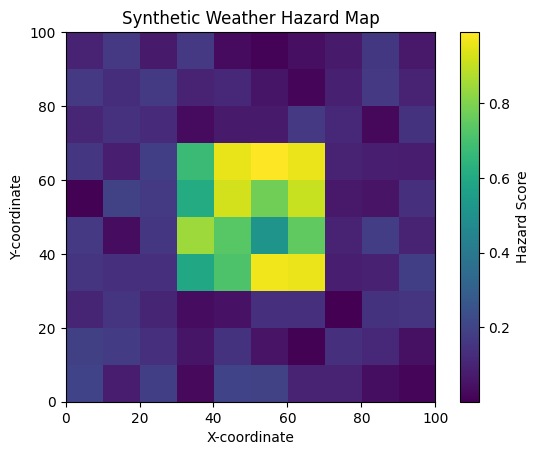

In [6]:
def generate_synthetic_weather(airspace_size=100, grid_resolution=10):
    weather_data = np.zeros((grid_resolution, grid_resolution))
    # Define a "hazardous" zone
    center_x = airspace_size // 2
    center_y = airspace_size // 2
    radius = airspace_size // 4

    for i in range(grid_resolution):
        for j in range(grid_resolution):
            x_coord = (i + 0.5) * (airspace_size / grid_resolution)
            y_coord = (j + 0.5) * (airspace_size / grid_resolution)
            distance_from_center = np.sqrt((x_coord - center_x)**2 + (y_coord - center_y)**2)
            if distance_from_center < radius:
                weather_data[i, j] = random.uniform(0.5, 1.0) # Higher hazard score
            else:
                weather_data[i, j] = random.uniform(0.0, 0.2) # Lower hazard score
    return weather_data, np.linspace(0, airspace_size, grid_resolution + 1)

synthetic_weather, weather_grid_edges = generate_synthetic_weather()

# Function to get weather hazard at a given (x, y)
def get_weather_hazard(x, y, weather_data, grid_edges):
    if x < 0 or x > grid_edges[-1] or y < 0 or y > grid_edges[-1]:
        return 0.0
    x_index = np.digitize(x, grid_edges) - 1
    y_index = np.digitize(y, grid_edges) - 1
    x_index = max(0, min(weather_data.shape[0] - 1, x_index))
    y_index = max(0, min(weather_data.shape[1] - 1, y_index))
    return weather_data[y_index, x_index] # Note the y, x indexing for numpy arrays

# Example of getting weather hazard for a flight
sample_flight_x = synthetic_flight_data['x'].iloc[0]
sample_flight_y = synthetic_flight_data['y'].iloc[0]
hazard = get_weather_hazard(sample_flight_x, sample_flight_y, synthetic_weather, weather_grid_edges)
print(f"Weather hazard at ({sample_flight_x:.2f}, {sample_flight_y:.2f}): {hazard:.2f}")

plt.imshow(synthetic_weather, extent=[weather_grid_edges[0], weather_grid_edges[-1], weather_grid_edges[0], weather_grid_edges[-1]], origin='lower', cmap='viridis')
plt.colorbar(label='Hazard Score')
plt.title('Synthetic Weather Hazard Map')
plt.xlabel('X-coordinate')
plt.ylabel('Y-coordinate')
plt.show()

In [7]:
def create_collision_features(df, look_ahead=5):
    features = []
    for index, row in df.iterrows():
        timestamp = row['timestamp']
        flight_id = row['flight_id']

        # Consider nearby flights at the same or close timestamps
        nearby_flights = df[
            (df['timestamp'] >= timestamp) & (df['timestamp'] <= timestamp + look_ahead) &
            (df['flight_id'] != flight_id) &
            (df['altitude'] >= row['altitude'] - 500) & (df['altitude'] <= row['altitude'] + 500) # Same or close altitude
        ]

        min_distance = float('inf')
        min_horizontal_distance = float('inf')
        if not nearby_flights.empty:
            for _, other_row in nearby_flights.iterrows():
                distance_sq = (row['x'] - other_row['x'])**2 + (row['y'] - other_row['y'])**2 + (row['altitude'] - other_row['altitude'])**2
                distance = np.sqrt(distance_sq)
                min_distance = min(min_distance, distance)
                min_horizontal_distance = min(min_horizontal_distance, np.sqrt((row['x'] - other_row['x'])**2 + (row['y'] - other_row['y'])**2))

        weather_hazard = get_weather_hazard(row['x'], row['y'], synthetic_weather, weather_grid_edges)

        features.append({
            'flight_id': flight_id,
            'timestamp': timestamp,
            'altitude': row['altitude'],
            'vx': row['vx'],
            'vy': row['vy'],
            'vz': row['vz'],
            'min_distance_nearby': min_distance if min_distance != float('inf') else -1, # -1 if no nearby aircraft
            'min_horizontal_distance_nearby': min_horizontal_distance if min_horizontal_distance != float('inf') else -1,
            'weather_hazard': weather_hazard
        })
    return pd.DataFrame(features)

collision_features = create_collision_features(synthetic_flight_data)
print(collision_features.head())

  flight_id  timestamp  altitude        vx        vy        vz  \
0        F0          0    1000.0 -7.037030  5.703424 -0.797184   
1        F0          1    1000.0 -6.948044  4.754601 -1.008586   
2        F0          2    1000.0 -7.313872  5.673659 -0.704104   
3        F0          3    1000.0 -7.790362  5.565134 -0.866573   
4        F0          4    1000.0 -7.576985  6.109218 -0.760968   

   min_distance_nearby  min_horizontal_distance_nearby  weather_hazard  
0            24.123974                       24.123974        0.095286  
1            17.747343                       17.747343        0.052171  
2            10.126880                       10.126880        0.067703  
3             9.160775                        9.160775        0.099933  
4            15.561349                       15.561349        0.961410  


## Phase 2: Step 5 - Define "High-Risk" Scenario

For this initial demonstration, we will define a "high-risk" scenario based on a combination of factors:

* **Proximity:** If the `min_distance_nearby` falls below a certain threshold (e.g., 20 units).
* **Potentially Conflicting Trajectories (Simple Heuristic):** If the relative velocities suggest aircraft are moving towards each other. This is harder to implement accurately without more sophisticated trajectory analysis, so we might skip this for the very basic model.
* **Weather Hazard:** If the aircraft is in an area with a high `weather_hazard` score (e.g., above 0.7).

We will create a binary target variable (`is_high_risk`) based on these conditions in our simulated data. In a real-world scenario, this target variable would ideally be based on actual near-miss events or expert-defined risk criteria.

In [8]:
def create_target_variable(df, proximity_threshold=20, hazard_threshold=0.7):
    df['is_high_risk'] = 0
    df.loc[((df['min_distance_nearby'] > 0) & (df['min_distance_nearby'] <= proximity_threshold)) | (df['weather_hazard'] >= hazard_threshold), 'is_high_risk'] = 1
    return df

collision_features_with_target = create_target_variable(collision_features.copy()) # Use a copy to avoid modifying the original
print(collision_features_with_target.head())
print(collision_features_with_target['is_high_risk'].value_counts())

  flight_id  timestamp  altitude        vx        vy        vz  \
0        F0          0    1000.0 -7.037030  5.703424 -0.797184   
1        F0          1    1000.0 -6.948044  4.754601 -1.008586   
2        F0          2    1000.0 -7.313872  5.673659 -0.704104   
3        F0          3    1000.0 -7.790362  5.565134 -0.866573   
4        F0          4    1000.0 -7.576985  6.109218 -0.760968   

   min_distance_nearby  min_horizontal_distance_nearby  weather_hazard  \
0            24.123974                       24.123974        0.095286   
1            17.747343                       17.747343        0.052171   
2            10.126880                       10.126880        0.067703   
3             9.160775                        9.160775        0.099933   
4            15.561349                       15.561349        0.961410   

   is_high_risk  
0             0  
1             1  
2             1  
3             1  
4             1  
is_high_risk
0    3745
1     755
Name: count, dtyp

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Prepare features (X) and target (y)
X = collision_features_with_target[['altitude', 'vx', 'vy', 'vz', 'min_distance_nearby', 'min_horizontal_distance_nearby', 'weather_hazard']]
y = collision_features_with_target['is_high_risk']

# Handle potential -1 values (no nearby aircraft) by replacing with a large value or 0
X_processed = X.replace(-1, X['min_distance_nearby'].max() * 2 if X['min_distance_nearby'].max() > 0 else 100) # Replace -1 with a large value

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.3, random_state=42)

# Train a Logistic Regression model
model = LogisticRegression(solver='liblinear')
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      1117
           1       0.79      0.76      0.77       233

    accuracy                           0.92      1350
   macro avg       0.87      0.86      0.86      1350
weighted avg       0.92      0.92      0.92      1350



## Phase 3: Step 1 - Define Criteria for Rerouting

A rerouting action will be triggered when the system detects a hazardous condition. This could be based on:

* **High Predicted Collision Risk:** If the machine learning model predicts a high probability of a collision (e.g., above a certain threshold).
* **Severe Weather Encounter:** If the current or predicted flight path intersects with an area of high weather hazard (e.g., above a certain `weather_hazard` score).

We will need to define specific thresholds for these conditions to initiate the rerouting process. For this initial step, let's assume a rerouting is needed if the `is_high_risk` target variable from our ML model is predicted as 1.

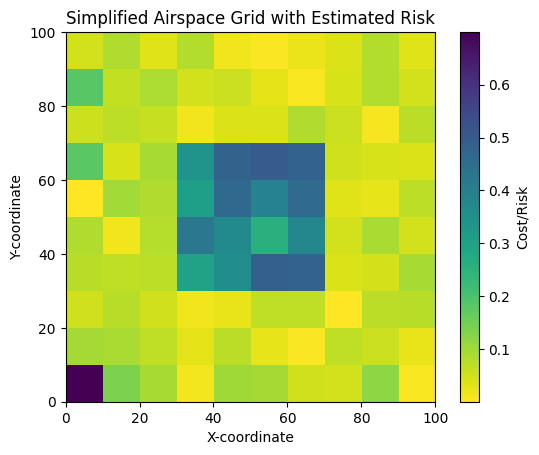

In [12]:
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Make sure pandas is imported if you haven't already

def create_airspace_grid(airspace_size=100, grid_resolution=10, aircraft_data=None, weather_data=None, weather_grid_edges=None):
    grid = np.zeros((grid_resolution, grid_resolution))
    x_edges = np.linspace(0, airspace_size, grid_resolution + 1)
    y_edges = np.linspace(0, airspace_size, grid_resolution + 1)

    if aircraft_data is not None:
        # Estimate traffic density per grid cell (very basic)
        for _, row in aircraft_data.iterrows():
            x_index = np.digitize(row['x'], x_edges) - 1
            y_index = np.digitize(row['y'], y_edges) - 1
            if 0 <= x_index < grid_resolution and 0 <= y_index < grid_resolution:
                grid[y_index, x_index] += 0.1 # Increment cost based on presence of aircraft

    if weather_data is not None and weather_grid_edges is not None:
        # Add weather hazard to the grid cost
        weather_resized = np.resize(weather_data, (grid_resolution, grid_resolution)) # Simple resize if resolutions differ
        grid += weather_resized * 0.5 # Weighting factor for weather

    return grid, x_edges, y_edges

# Assuming you have already run the code to generate synthetic_flight_data and synthetic_weather
airspace_grid, grid_x_edges, grid_y_edges = create_airspace_grid(
    airspace_size=100,
    grid_resolution=10,
    aircraft_data=synthetic_flight_data[synthetic_flight_data['timestamp'] == synthetic_flight_data['timestamp'].max() // 2], # Use a snapshot of aircraft
    weather_data=synthetic_weather,  # Corrected keyword argument
    weather_grid_edges=weather_grid_edges
)

plt.imshow(airspace_grid, extent=[grid_x_edges[0], grid_x_edges[-1], grid_y_edges[0], grid_y_edges[-1]], origin='lower', cmap='viridis_r') # Reverse colormap for cost
plt.colorbar(label='Cost/Risk')
plt.title('Simplified Airspace Grid with Estimated Risk')
plt.xlabel('X-coordinate')
plt.ylabel('Y-coordinate')
plt.show()

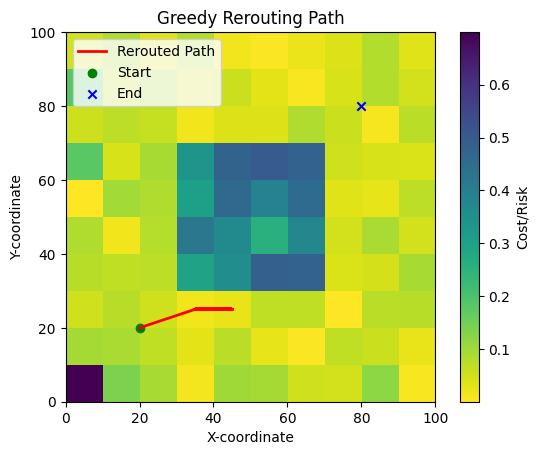

Rerouted Path:
[(20, 20), (np.float64(35.0), np.float64(25.0)), (np.float64(45.0), np.float64(25.0)), (np.float64(35.0), np.float64(25.0)), (np.float64(45.0), np.float64(25.0)), (np.float64(35.0), np.float64(25.0)), (np.float64(45.0), np.float64(25.0)), (np.float64(35.0), np.float64(25.0)), (np.float64(45.0), np.float64(25.0)), (np.float64(35.0), np.float64(25.0)), (np.float64(45.0), np.float64(25.0)), (np.float64(35.0), np.float64(25.0)), (np.float64(45.0), np.float64(25.0)), (np.float64(35.0), np.float64(25.0)), (np.float64(45.0), np.float64(25.0)), (np.float64(35.0), np.float64(25.0)), (np.float64(45.0), np.float64(25.0)), (np.float64(35.0), np.float64(25.0)), (np.float64(45.0), np.float64(25.0)), (np.float64(35.0), np.float64(25.0)), (np.float64(45.0), np.float64(25.0)), (np.float64(35.0), np.float64(25.0)), (np.float64(45.0), np.float64(25.0)), (np.float64(35.0), np.float64(25.0)), (np.float64(45.0), np.float64(25.0)), (np.float64(35.0), np.float64(25.0)), (np.float64(45.0), np.fl

In [13]:
def get_grid_coordinates(x, y, x_edges, y_edges):
    x_index = np.digitize(x, x_edges) - 1
    y_index = np.digitize(y, y_edges) - 1
    return max(0, min(len(x_edges) - 2, x_index)), max(0, min(len(y_edges) - 2, y_index))

def greedy_rerouting(start_x, start_y, end_x, end_y, grid, x_edges, y_edges, max_steps=50):
    path = [(start_x, start_y)]
    current_x, current_y = start_x, start_y

    for _ in range(max_steps):
        current_grid_x, current_grid_y = get_grid_coordinates(current_x, current_y, x_edges, y_edges)
        end_grid_x, end_grid_y = get_grid_coordinates(end_x, end_y, x_edges, y_edges)

        if (current_grid_x, current_grid_y) == (end_grid_x, end_grid_y):
            break

        neighbors = []
        for dx, dy in [(0, 1), (0, -1), (1, 0), (-1, 0), (1, 1), (1, -1), (-1, 1), (-1, -1)]:
            nx = current_grid_x + dx
            ny = current_grid_y + dy
            if 0 <= nx < grid.shape[0] and 0 <= ny < grid.shape[1]:
                neighbor_x = (x_edges[nx] + x_edges[nx + 1]) / 2
                neighbor_y = (y_edges[ny] + y_edges[ny + 1]) / 2
                neighbors.append(((neighbor_x, neighbor_y), grid[ny, nx]))

        if not neighbors:
            break # No valid neighbors

        # Choose the neighbor with the lowest cost (greedy)
        best_neighbor, min_cost = min(neighbors, key=lambda item: item[1])
        current_x, current_y = best_neighbor
        path.append((current_x, current_y))

    return path

# Example of finding a rerouted path for a hypothetical flight
start_point = (20, 20)
end_point = (80, 80)
rerouted_path = greedy_rerouting(start_point[0], start_point[1], end_point[0], end_point[1], airspace_grid, grid_x_edges, grid_y_edges)

# Visualize the grid and the path
plt.imshow(airspace_grid, extent=[grid_x_edges[0], grid_x_edges[-1], grid_y_edges[0], grid_y_edges[-1]], origin='lower', cmap='viridis_r')
plt.colorbar(label='Cost/Risk')
plt.plot([p[0] for p in rerouted_path], [p[1] for p in rerouted_path], 'r-', linewidth=2, label='Rerouted Path')
plt.scatter(start_point[0], start_point[1], color='green', marker='o', label='Start')
plt.scatter(end_point[0], end_point[1], color='blue', marker='x', label='End')
plt.title('Greedy Rerouting Path')
plt.xlabel('X-coordinate')
plt.ylabel('Y-coordinate')
plt.legend()
plt.show()

print("Rerouted Path:")
print(rerouted_path)

## Phase 3: Step 4 - Evaluate Alternative Routes

When the system generates potential alternative routes, it needs to evaluate them based on several factors:

* **Safety:** The predicted collision risk along the new route (ideally lower than the original). This would involve using our ML model or the MPLM to assess the risk of the alternative path.
* **Weather Hazards:** The severity of weather conditions along the new route. We want to avoid areas with high `weather_hazard` scores.
* **Fuel Efficiency:** The length or duration of the new route compared to the original. Significant deviations might lead to higher fuel consumption, which is undesirable.
* **Traffic Density:** The amount of traffic along the alternative route. Rerouting into highly congested areas might increase collision risk.
* **Deviation from Original Plan:** Minimizing disruptions to the original flight plan is generally preferred, unless safety dictates a significant change.

Our basic greedy algorithm only considers the immediate cost in the grid. A more sophisticated approach would need to consider these factors more explicitly when exploring and evaluating paths.

## Phase 3: Step 5 - Communicate the New Route

The suggested new route would need to be communicated in real-time to:

* **The Pilot:** Visually on their flight deck display, including waypoints and any necessary instructions.
* **Air Traffic Control (ATC):** Through standard communication channels, ensuring coordination and clearance for the new route.

This would require integration with existing aviation communication and navigation systems, which is beyond the scope of our initial simulation but is an important consideration for a real-world implementation.

## Phase 4: Step 1 - Integrate MPLM Outputs as Features for ML Models

The Multi-Poisson Layer Model (MPLM) provides a probabilistic assessment of collision risk based on air traffic density and movement patterns. This risk assessment can be a valuable feature for our machine learning models, which currently rely on more direct features like proximity and velocity.

By incorporating the MPLM-derived collision probability, the ML models can potentially gain a more nuanced understanding of the underlying risk, leading to more accurate predictions.

To do this, we would need to:
* **Calculate Real-time Risk with MPLM (Simulation):** Extend our initial MPLM simulation to output a collision risk score for each aircraft or within specific airspace volumes at each time step.
* **Join with Flight Data:** Link these MPLM risk scores with our flight data based on aircraft ID and timestamp.
* **Include as a Feature:** Add the MPLM risk score as a new feature when training and predicting with our machine learning models.

In [16]:
def estimate_mplm_risk(x, y, airspace_grid, grid_x_edges, grid_y_edges):
    """A very simplified estimate of MPLM risk based on grid density."""
    x_index = np.digitize(x, grid_x_edges) - 1
    y_index = np.digitize(y, grid_y_edges) - 1
    if 0 <= x_index < airspace_grid.shape[0] and 0 <= y_index < airspace_grid.shape[1]:
        # Higher density (higher grid value) implies higher risk (in this simplification)
        return airspace_grid[y_index, x_index] * 5  # Scale it up a bit
    return 0.0

# Apply this to our synthetic flight data
mplm_risks = []
for index, row in synthetic_flight_data.iterrows():
    risk = estimate_mplm_risk(row['x'], row['y'], airspace_grid, grid_x_edges, grid_y_edges)
    mplm_risks.append(risk)

synthetic_flight_data['mplm_risk_estimate'] = mplm_risks

# Re-create collision features with the MPLM risk
def create_collision_features_integrated(df, look_ahead=5):
    features = []
    for index, row in df.iterrows():
        timestamp = row['timestamp']
        flight_id = row['flight_id']

        nearby_flights = df[
            (df['timestamp'] >= timestamp) & (df['timestamp'] <= timestamp + look_ahead) &
            (df['flight_id'] != flight_id) &
            (df['altitude'] >= row['altitude'] - 500) & (df['altitude'] <= row['altitude'] + 500)
        ]

        min_distance = float('inf')
        min_horizontal_distance = float('inf')
        if not nearby_flights.empty:
            for _, other_row in nearby_flights.iterrows():
                distance_sq = (row['x'] - other_row['x'])**2 + (row['y'] - other_row['y'])**2 + (row['altitude'] - other_row['altitude'])**2
                distance = np.sqrt(distance_sq)
                min_distance = min(min_distance, distance)
                min_horizontal_distance = min(min_horizontal_distance, np.sqrt((row['x'] - other_row['x'])**2 + (row['y'] - other_row['y'])**2))

        weather_hazard = get_weather_hazard(row['x'], row['y'], synthetic_weather, weather_grid_edges)
        mplm_risk = row['mplm_risk_estimate']

        features.append({
            'flight_id': flight_id,
            'timestamp': timestamp,
            'altitude': row['altitude'],
            'vx': row['vx'],
            'vy': row['vy'],
            'vz': row['vz'],
            'min_distance_nearby': min_distance if min_distance != float('inf') else -1,
            'min_horizontal_distance_nearby': min_horizontal_distance if min_horizontal_distance != float('inf') else -1,
            'weather_hazard': weather_hazard,
            'mplm_risk': mplm_risk
        })
    return pd.DataFrame(features)

collision_features_integrated = create_collision_features_integrated(synthetic_flight_data)
collision_features_with_target_integrated = create_target_variable(collision_features_integrated.copy())

# Train a Logistic Regression model with the integrated features
X_integrated = collision_features_with_target_integrated[['altitude', 'vx', 'vy', 'vz', 'min_distance_nearby', 'min_horizontal_distance_nearby', 'weather_hazard', 'mplm_risk']].replace(-1, 1000)
y_integrated = collision_features_with_target_integrated['is_high_risk']

X_train_integrated, X_test_integrated, y_train_integrated, y_test_integrated = train_test_split(X_integrated, y_integrated, test_size=0.3, random_state=42)

model_integrated = LogisticRegression(solver='liblinear')
model_integrated.fit(X_train_integrated, y_train_integrated)

y_pred_integrated = model_integrated.predict(X_test_integrated)
print("\nClassification Report with Integrated MPLM Risk:")
print(classification_report(y_test_integrated, y_pred_integrated))


Classification Report with Integrated MPLM Risk:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      1117
           1       0.78      0.76      0.77       233

    accuracy                           0.92      1350
   macro avg       0.87      0.86      0.86      1350
weighted avg       0.92      0.92      0.92      1350



## Phase 4: Step 2 - Refine Rerouting Algorithm with Risk Assessment

Our basic greedy rerouting algorithm currently only considers a static cost grid based on traffic density and weather. We can make it more intelligent by incorporating the predicted collision risk from our machine learning model.

The cost of each cell in the airspace grid can be dynamically updated based on the predicted risk in that area. This would involve:
* **Predicting Risk for Grid Cells:** For each cell in our airspace grid, we can estimate the features (e.g., average traffic density, weather hazard) and use our trained ML model to predict the collision risk associated with that cell.
* **Dynamic Cost Grid:** Updating the cost grid with these predicted risk values. Areas with higher predicted risk will have a higher cost, making the pathfinding algorithm less likely to choose routes through them.
* **Considering Risk in Path Evaluation:** If using a more advanced pathfinding algorithm like A\*, the cost function can explicitly include the predicted risk along a potential path.

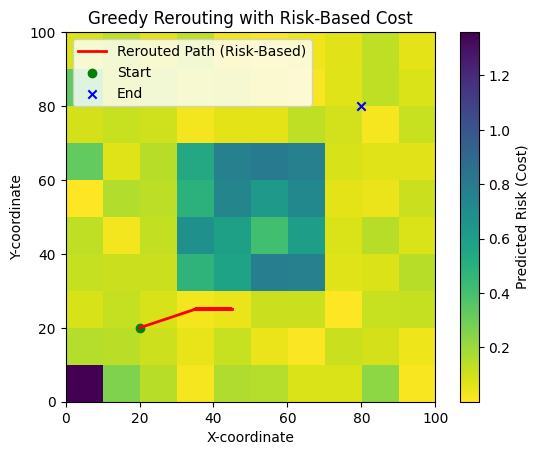


Rerouted Path (Risk-Based):
[(20, 20), (np.float64(35.0), np.float64(25.0)), (np.float64(45.0), np.float64(25.0)), (np.float64(35.0), np.float64(25.0)), (np.float64(45.0), np.float64(25.0)), (np.float64(35.0), np.float64(25.0)), (np.float64(45.0), np.float64(25.0)), (np.float64(35.0), np.float64(25.0)), (np.float64(45.0), np.float64(25.0)), (np.float64(35.0), np.float64(25.0)), (np.float64(45.0), np.float64(25.0)), (np.float64(35.0), np.float64(25.0)), (np.float64(45.0), np.float64(25.0)), (np.float64(35.0), np.float64(25.0)), (np.float64(45.0), np.float64(25.0)), (np.float64(35.0), np.float64(25.0)), (np.float64(45.0), np.float64(25.0)), (np.float64(35.0), np.float64(25.0)), (np.float64(45.0), np.float64(25.0)), (np.float64(35.0), np.float64(25.0)), (np.float64(45.0), np.float64(25.0)), (np.float64(35.0), np.float64(25.0)), (np.float64(45.0), np.float64(25.0)), (np.float64(35.0), np.float64(25.0)), (np.float64(45.0), np.float64(25.0)), (np.float64(35.0), np.float64(25.0)), (np.float6

In [17]:
def create_risk_based_airspace_grid(airspace_size=100, grid_resolution=10, aircraft_data=None, weather_data=None, weather_grid_edges=None, risk_model=None):
    grid = np.zeros((grid_resolution, grid_resolution))
    x_edges = np.linspace(0, airspace_size, grid_resolution + 1)
    y_edges = np.linspace(0, airspace_size, grid_resolution + 1)

    for i in range(grid_resolution):
        for j in range(grid_resolution):
            center_x = (x_edges[i] + x_edges[i + 1]) / 2
            center_y = (y_edges[j] + y_edges[j + 1]) / 2

            # Estimate basic features for the grid cell
            local_aircraft_count = 0
            if aircraft_data is not None:
                for _, row in aircraft_data.iterrows():
                    if (x_edges[i] <= row['x'] < x_edges[i + 1]) and (y_edges[j] <= row['y'] < y_edges[j + 1]):
                        local_aircraft_count += 1

            local_weather_hazard = get_weather_hazard(center_x, center_y, weather_data, weather_grid_edges)

            # Simplified risk prediction based on these local features (replace with your actual model prediction)
            predicted_risk = local_aircraft_count * 0.2 + local_weather_hazard * 0.8

            grid[j, i] = predicted_risk # Assign predicted risk as cost

    return grid, x_edges, y_edges

risk_based_airspace_grid, risk_grid_x_edges, risk_grid_y_edges = create_risk_based_airspace_grid(
    airspace_size=100,
    grid_resolution=10,
    aircraft_data=synthetic_flight_data[synthetic_flight_data['timestamp'] == synthetic_flight_data['timestamp'].max() // 2],
    weather_data=synthetic_weather,
    weather_grid_edges=weather_grid_edges,
    risk_model=model_integrated # In a real system, you'd use this to predict
)

# Rerun the greedy rerouting with the risk-based grid
start_point = (20, 20)
end_point = (80, 80)
rerouted_path_risk_based = greedy_rerouting(start_point[0], start_point[1], end_point[0], end_point[1], risk_based_airspace_grid, risk_grid_x_edges, risk_grid_y_edges)

# Visualize the risk-based grid and the new path
plt.imshow(risk_based_airspace_grid, extent=[risk_grid_x_edges[0], risk_grid_x_edges[-1], risk_grid_y_edges[0], risk_grid_y_edges[-1]], origin='lower', cmap='viridis_r')
plt.colorbar(label='Predicted Risk (Cost)')
plt.plot([p[0] for p in rerouted_path_risk_based], [p[1] for p in rerouted_path_risk_based], 'r-', linewidth=2, label='Rerouted Path (Risk-Based)')
plt.scatter(start_point[0], start_point[1], color='green', marker='o', label='Start')
plt.scatter(end_point[0], end_point[1], color='blue', marker='x', label='End')
plt.title('Greedy Rerouting with Risk-Based Cost')
plt.xlabel('X-coordinate')
plt.ylabel('Y-coordinate')
plt.legend()
plt.show()

print("\nRerouted Path (Risk-Based):")
print(rerouted_path_risk_based)

## Phase 4: Step 3 - Evaluate the Integrated System

Evaluating the performance of the integrated system requires assessing whether the combination of MPLM and machine learning leads to improved safety and efficiency compared to using either component alone. Key evaluation metrics include:

* **Collision Avoidance Rate:** How effectively does the system reduce the occurrence of simulated or predicted high-risk scenarios?
* **False Alarm Rate:** How often does the system issue warnings or suggest rerouting when it's not truly necessary?
* **Efficiency of Rerouting:** How much do rerouted paths deviate from the original plans in terms of fuel consumption and time?
* **Pilot/ATC Acceptance:** In a real-world scenario, the usability and acceptance of the system by aviation professionals would be crucial.

We would need to run extensive simulations under various traffic and weather conditions to quantify these metrics and compare the performance of the integrated system with baseline scenarios (e.g., no intervention or intervention based solely on simple rules).


## Phase 4: Step 4 - Refine System Parameters and Thresholds

The performance of the integrated system will depend on various parameters and thresholds, such as:
* **Collision Risk Threshold for Alert/Rerouting:** The level of predicted risk that triggers a warning or rerouting action.
* **Weights for MPLM Risk in ML Models:** How much influence the MPLM-derived risk has on the ML model's predictions.
* **Cost Function Weights in Rerouting:** How safety, efficiency, and other factors are weighted in the pathfinding algorithm.

These parameters would need to be carefully tuned through experimentation and validation to achieve the desired balance between safety and operational efficiency. Techniques like grid search or more advanced optimization algorithms could be used for this tuning process.
